# QVAE

Reimplements the core model from [gersteinlab/QVAE](https://github.com/gersteinlab/QVAE),
mirroring the structure of `vae.ipynb` / `svae.ipynb` / `poisson_vae.ipynb` (data → model →
train → sample → reconstructions → interpolations).

The official repo is a Qiskit 0.43 / `qiskit-machine-learning` research script built around
gradient-free optimizers (COBYLA/SPSA) acting on `DensityMatrix` objects, tied to its own
swiss-roll/gene datasets and file-based CLI (`QVAE.py`, `core.py`, `embedding.py`). It is not
pip-installable against current Qiskit and predates this survey's MNIST/PyTorch baseline, so
instead of importing it directly this notebook ports its load-bearing pieces — the
Ising-interaction encoder/decoder ansatz (`embedding.py::ising_interaction_noInput`), the
trash-qubit bottleneck via partial trace (`core.py::QVAE_NN.forward`), and the
fidelity-reconstruction / JSD-regularizer objective against the maximally mixed state
(`core.py::DensityMatrix_ObjectiveFunction`) — as plain `torch` tensor ops, verbatim in spirit,
wired into the same MNIST pipeline used elsewhere in this survey. Since every op used (RZZ/RY
rotations, partial trace, fidelity, matrix log) is differentiable, we train with Adam instead
of the original COBYLA — a practical swap that keeps the model's math unchanged.

A **quantum autoencoder** here plays the role of a VAE: the encoder is a parameterized unitary
acting on the input state, some of its qubits ("trash qubits") are traced out to form an
information bottleneck (the latent), and a regularizer pulls the traced-out latent state
toward the maximally mixed state — the quantum analogue of a VAE's KL-to-standard-normal term.
The decoder is a second parameterized unitary that re-expands the latent (padded with a fixed
`|0...0>` reconstruction register) back to the input dimension.

In [1]:
import math
import pathlib
import sys

import torch
import torch.nn as nn
import torchvision.datasets as datasets

for _root in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_root / "vae" / "models").is_dir():
        sys.path.insert(0, str(_root))
        break

from vae.models.qvae import QVAE
from vae.handlers.qvae import (
    to_amplitude_states,
    to_density_matrices,
    reconstruction_loss,
    jsd_regularizer,
    random_pure_states,
    density_diag_to_image,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float64)  # unitary/fidelity math is numerically sensitive

## Data

Same MNIST split used by `vae.ipynb`, but amplitude-encoded into pure quantum states rather
than kept as pixel intensities. Qiskit simulation of dense two-qubit gates on all pairs is
exponential in qubit count, so — matching the original repo's small swiss-roll/gene inputs
(8 and 16 features) — we downsample each 28x28 image to 8x8=64=2^6 pixels (`n_qubit=6`) and
L2-normalize each flattened image to a unit vector, exactly `preprocessing.py::normalize_amplitude`.
A unit vector `x` is then a valid quantum statevector, and `|x><x|` (`core.py` builds inputs
with `qi.DensityMatrix(x).data`) is its density matrix.

In [2]:
mnist_trainset = datasets.MNIST(root='../../data', train=True, download=True, transform=None)

n_qubit = 6
res = 2 ** (n_qubit // 2)  # 8x8 = 64 = 2^6

train_dataset = to_amplitude_states(mnist_trainset.data[:-10000])
eval_dataset = to_amplitude_states(mnist_trainset.data[-10000:])

## Ising-interaction ansatz

Ported from `embedding.py::ising_interaction_noInput`: `n_layers` blocks of an all-pairs `RZZ`
entangling layer followed by a per-qubit `RY` rotation. Built here as dense `2^n x 2^n` unitary
matrices (Kronecker products of single-/two-qubit gates) acting on density matrices by
conjugation, `rho -> U rho U^dagger`, which is what `core.py`'s `DensityMatrix.evolve(qc)` does
under the hood.

## Partial trace

Ported from the repeated `qi.partial_trace(state, qubits)` + renormalize pattern in
`core.py::QVAE_NN.forward`, used both to trace out the trash qubits (encoder -> latent
bottleneck) and to trace out auxiliary qubits after the decoder unitary.

## Model

`n_qubit=6` total, with `n_trash` qubits (default 2, matching the original's
`--num_trash_qubits`) traced out after the encoder to form the latent bottleneck (`n_qubit -
n_trash` qubits). The decoder pads the latent back out with a fixed `|0...0><0...0|`
"reconstruction register" of `n_trash` qubits (`core.py`'s `zero_state` /
`reconstruction_qubits`) before applying its own Ising-interaction unitary, and the output is
read straight off the full `n_qubit`-qubit density matrix (no auxiliary qubits, matching the
default `num_auxiliary_encoder=num_auxiliary_decoder=0`).

## Objective: fidelity reconstruction + JSD regularizer

Ported from `core.py::DensityMatrix_ObjectiveFunction`: `objective = reconstruction_loss +
beta * quantum_relative_entropy`. We use the repo's default `reconstruction_loss='fidelity'`
(negative mean quantum state fidelity between input and output) and `regularizer_type='JSD'`
(mean Jensen-Shannon divergence between each latent state and the maximally mixed state
`I/2^n_latent`) — the quantum analogue of a VAE's `-fidelity` reconstruction term and
`KL(q(z|x) || p(z))` prior term. `beta` is linearly annealed from 0 to 1 as in the other
notebooks in this survey.

## Training

Batched over density matrices built from the amplitude-encoded images (`|x><x|`, matching
`Xtrain_dm.append(qi.DensityMatrix(x).data)` in `QVAE.py`). Building the `2^n_qubit x
2^n_qubit` Ising-interaction unitary from scratch every step (a Python loop over `O(n_qubit^2)`
gates) is the dominant cost and is independent of batch size, so — unlike the other notebooks
in this survey — more steps matters far more here than a bigger batch. MNIST is also much
larger than the original repo's swiss-roll/gene datasets (a few hundred rows), so instead of
looping over all 50000 training images every epoch, each "epoch" here draws one fresh random
subset of `steps_per_epoch * batch_size` images — enough steps to actually move the loss in a
few minutes on a single GPU. Increase `steps_per_epoch` / `num_epochs` for a better-trained
model once you've confirmed the loop is progressing.

In [3]:
model = QVAE(n_qubit=n_qubit, n_trash=2, n_layers=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

num_epochs = 5  # Change this to train the model a bit more
steps_per_epoch = 100  # Change this to train on more data per epoch
batch_size = 32
beta_max = 1.0
log_every = 10

train_x = train_dataset.to(device)

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for step in range(steps_per_epoch):
        idx = torch.randint(0, len(train_x), (batch_size,), device=device)
        rho = to_density_matrices(train_x[idx])

        progress = (epoch * steps_per_epoch + step) / (num_epochs * steps_per_epoch)
        beta = min(beta_max, progress * 2)

        recon, latent = model(rho)
        recon_l = reconstruction_loss(recon, rho)
        reg_l = jsd_regularizer(latent)
        loss = recon_l + beta * reg_l

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        if (step + 1) % log_every == 0:
            print(f"  epoch {epoch + 1}/{num_epochs}  step {step + 1}/{steps_per_epoch}  "
                  f"recon_loss={recon_l.item():.4f}  jsd={reg_l.item():.4f}")

    print(f"epoch {epoch + 1}/{num_epochs}  avg loss={epoch_loss / steps_per_epoch:.4f}")

  epoch 1/5  step 10/100  recon_loss=-0.0975  jsd=0.6599


  epoch 1/5  step 20/100  recon_loss=-0.1749  jsd=0.6502


  epoch 1/5  step 30/100  recon_loss=-0.2878  jsd=0.6648


  epoch 1/5  step 40/100  recon_loss=-0.3831  jsd=0.6704


  epoch 1/5  step 50/100  recon_loss=-0.4435  jsd=0.6756


...

  epoch 5/5  step 60/100  recon_loss=-0.5569  jsd=0.6529


  epoch 5/5  step 70/100  recon_loss=-0.5567  jsd=0.6515


  epoch 5/5  step 80/100  recon_loss=-0.5926  jsd=0.6668


  epoch 5/5  step 90/100  recon_loss=-0.5973  jsd=0.6628


  epoch 5/5  step 100/100  recon_loss=-0.5948  jsd=0.6658
epoch 5/5  avg loss=0.0891


## Visualizing samples

The original repo has no generative sampler (it is trained/evaluated purely on
reconstruction fidelity). Analogous to `NormalSampler` in `vae.ipynb`, we sample the latent
from the maximally mixed state's eigenbasis — i.e. draw a Haar-random pure state on the latent
qubits, whose density matrix has the same marginal statistics the JSD regularizer pushes the
encoder's output toward — and decode it.

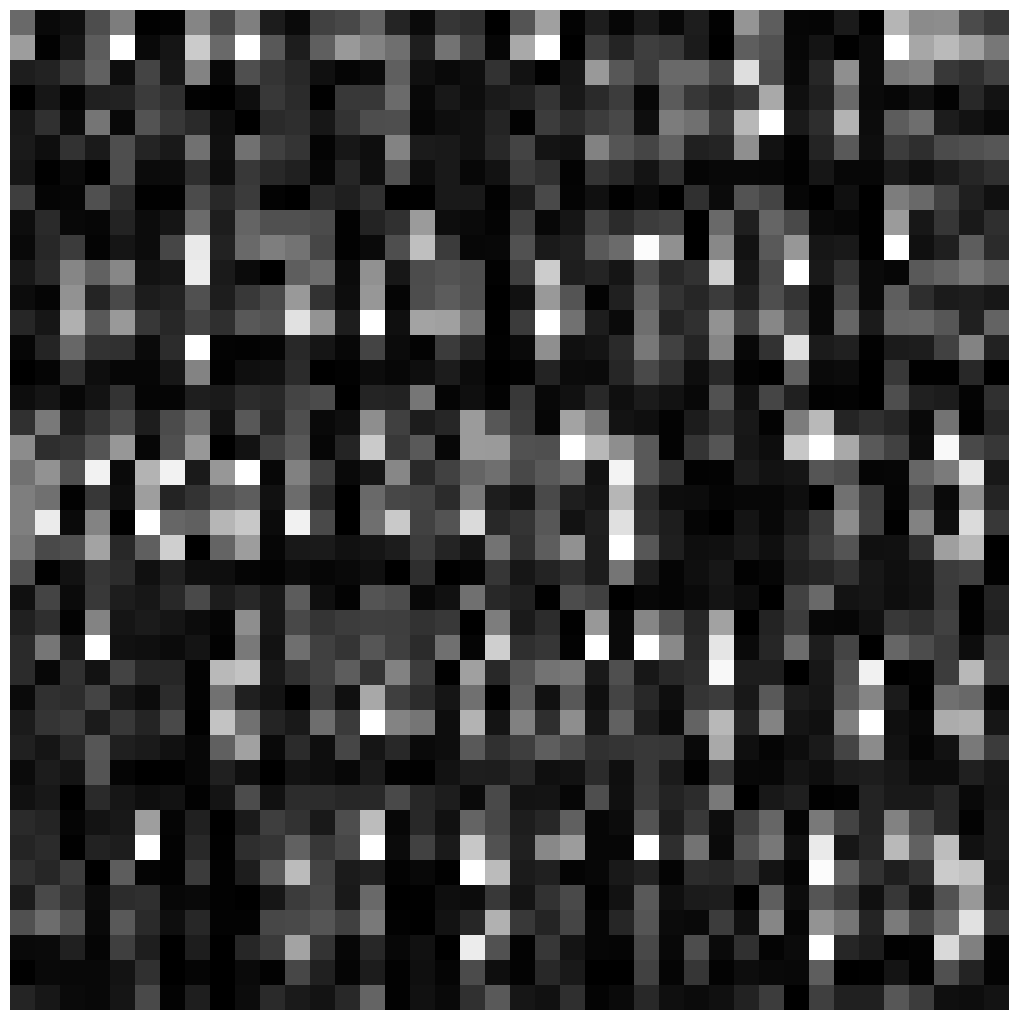

In [4]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    z = random_pure_states(25, 2 ** model.n_latent).to(device)
    latent_rho = to_density_matrices(z)
    gen_data = model.decode(latent_rho)
    gen_data = density_diag_to_image(gen_data).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(gen_data[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing reconstructions

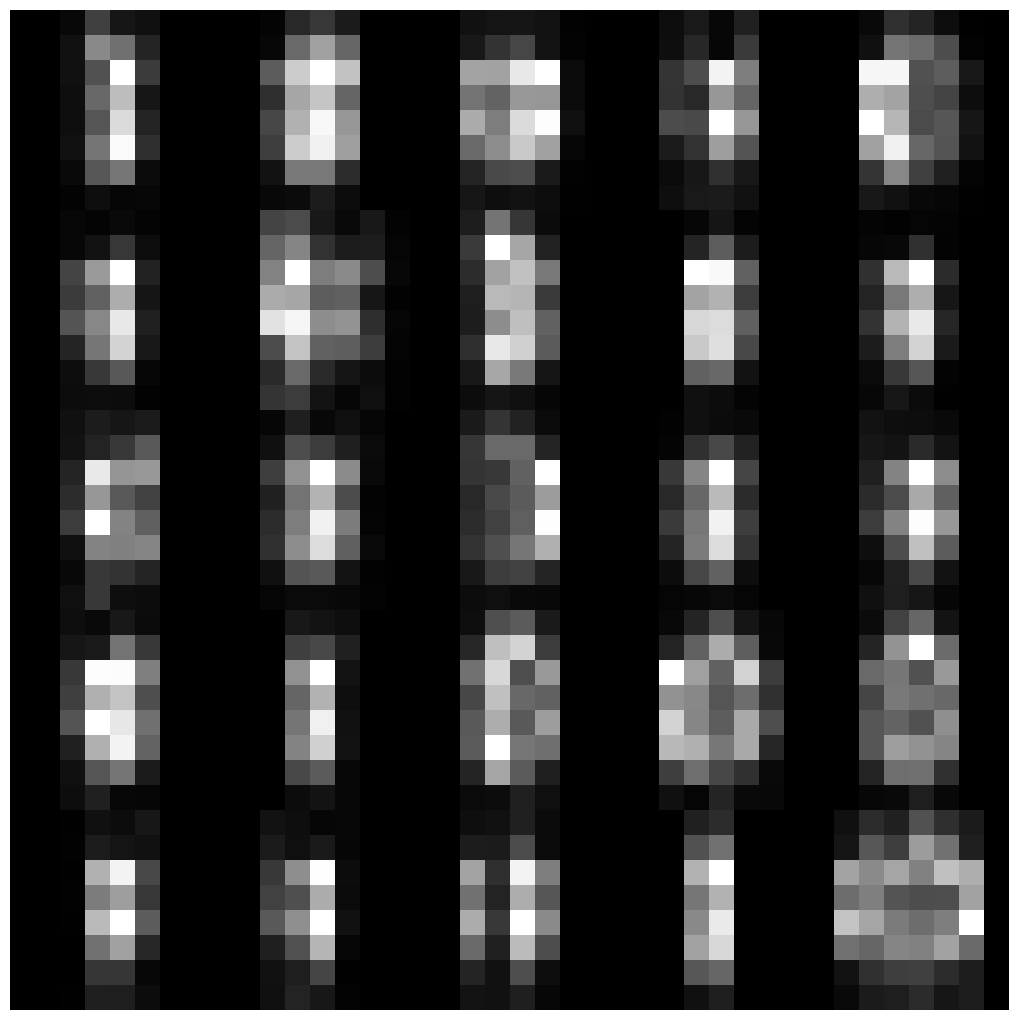

In [5]:
eval_x = eval_dataset[:25].to(device)
with torch.no_grad():
    eval_rho = to_density_matrices(eval_x)
    recon, _ = model(eval_rho)
    reconstructions = density_diag_to_image(recon).cpu()

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(reconstructions[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

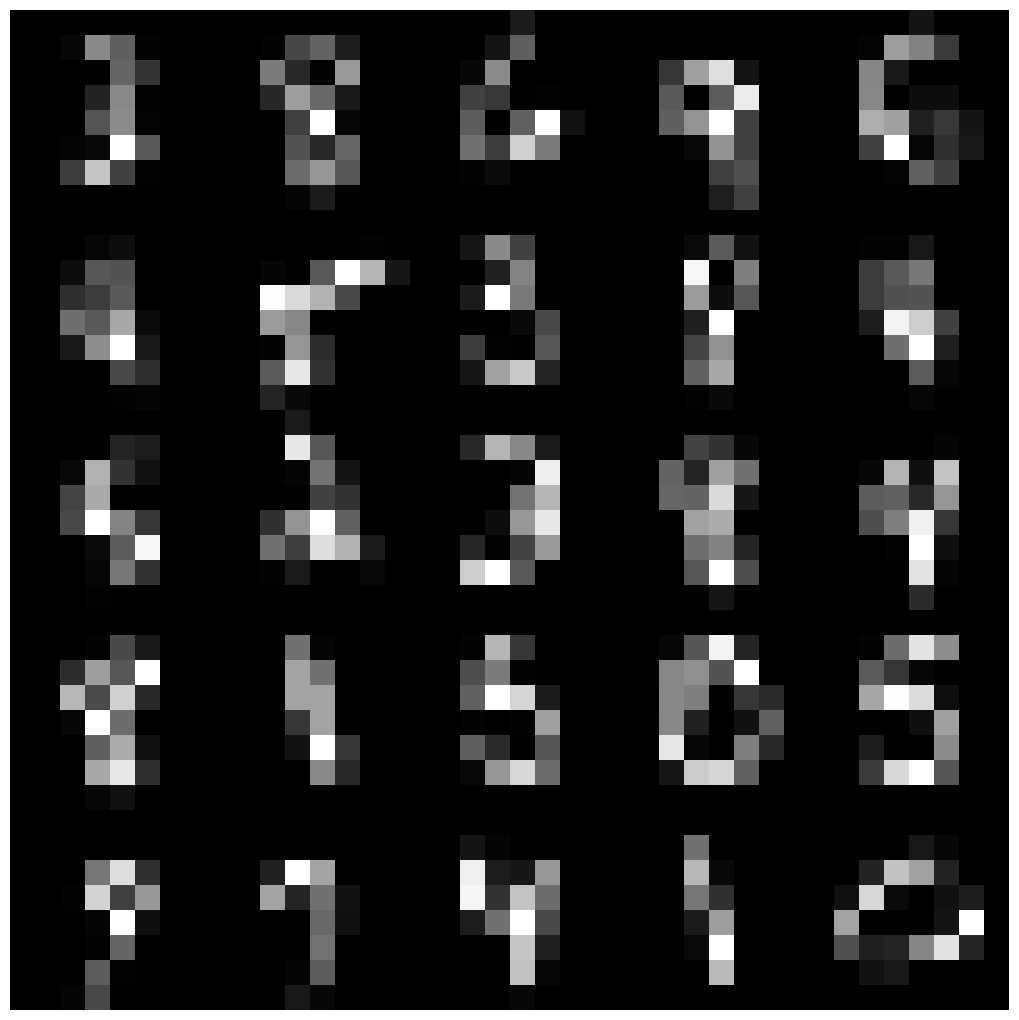

In [6]:
# show the true data
true_images = (eval_x.cpu() ** 2).reshape(-1, res, res)  # amplitudes^2 = pixel probabilities

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
for i in range(5):
    for j in range(5):
        axes[i][j].imshow(true_images[i * 5 + j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)

## Visualizing interpolations

The official repo has no interpolation utility. Since latents here are density matrices rather
than a vector space, linear (convex) interpolation between two latent density matrices —
`(1-a) rho1 + a rho2`, itself always a valid density matrix — is the natural analogue of the
Gaussian-latent interpolation used in `vae.ipynb`.

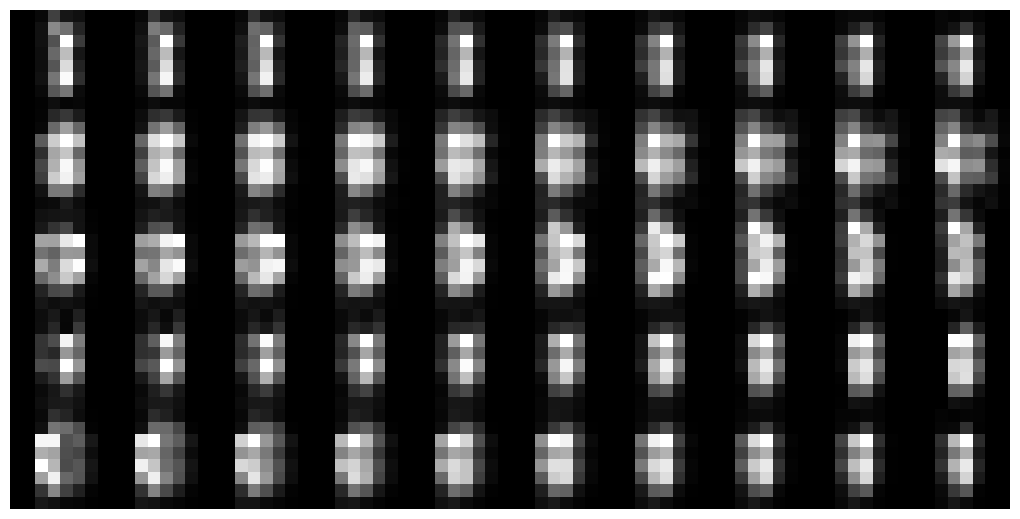

In [7]:
x1 = eval_dataset[:5].to(device)
x2 = eval_dataset[5:10].to(device)

with torch.no_grad():
    z1 = model.encode(to_density_matrices(x1))
    z2 = model.encode(to_density_matrices(x2))

    granularity = 10
    alphas = torch.linspace(0, 1, granularity, device=device)
    frames = []
    for a in alphas:
        z_interp = (1 - a) * z1 + a * z2
        frames.append(model.decode(z_interp))
    interpolations = torch.stack(frames)  # (granularity, 5, dim, dim)
    interpolations = density_diag_to_image(interpolations.reshape(-1, *interpolations.shape[-2:]))
    interpolations = interpolations.reshape(granularity, 5, res, res).permute(1, 0, 2, 3).cpu()

fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(10, 5))
for i in range(5):
    for j in range(10):
        axes[i][j].imshow(interpolations[i, j], cmap='gray')
        axes[i][j].axis('off')
plt.tight_layout(pad=0.)